In [1]:
import subprocess, sys

for pkg in [
    "transformers", "datasets", "torch", "scikit-learn",
    "pandas", "numpy", "tqdm", "matplotlib", "sentencepiece",
    "seaborn", "langdetect", "requests", "beautifulsoup4",
    "nltk", "ftfy"
]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
All packages ready.


In [2]:
import os, json, random, warnings, re, unicodedata
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from tqdm.auto import tqdm
import nltk
import ftfy
warnings.filterwarnings("ignore")
nltk.download("wordnet", quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), "Enable GPU: Settings -> Accelerator -> GPU T4"
DEVICE = torch.device("cuda")
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0)})")

INPUT_DIR = "/kaggle/input/datasets"
WORK_DIR  = "/kaggle/working"

LABELS = ["clean", "profanity", "hate_speech", "threat", "identity_attack"]
print(f"Labels: {LABELS}")


Device: cuda (Tesla T4)
Labels: ['clean', 'profanity', 'hate_speech', 'threat', 'identity_attack']


## Dataset Loading

### Sources
| Source | Language | Type |
|--------|----------|------|
| Jigsaw Toxic Comments | English | Primary |
| HatEval 2019 (GitHub) | English | Hate/threat |
| ETHOS dataset | English | Hate/identity |
| **NEHATE (native Nepali tweets)** | **Nepali** | **Binary hate — NEW** |
| **Offensive Terms Lexicon** | **Nepali** | **Keyword augmentation — NEW** |
| nep-off-langdetect NER | Nepali | BIO-tagged |
| nep-off-langdetect CSV | Nepali | Sentence-level |
| OSCAR CC-100 (scraped) | Nepali | Clean sentences |
| Scraped web comments | Code-switched | Mixed EN+NE |
| Synthetic via NLLB-200-distilled-600M | Nepali | Translated |

**NEW — NEHATE**: 13,505 native Nepali tweets with binary hate/clean labels.

**NEW — Offensive Terms Lexicon**: 1,077 Nepali terms with offensiveness scores,
taboo flags, and semantic classes. Used for keyword labelling and augmentation.

In [3]:
jigsaw_df = None
JIGSAW_PATH = os.path.join(
    INPUT_DIR, "julian3833",
    "jigsaw-toxic-comment-classification-challenge", "train.csv"
)
try:
    jigsaw_df = pd.read_csv(JIGSAW_PATH)
    print(f"Jigsaw loaded: {len(jigsaw_df):,} rows")
    print(jigsaw_df[["toxic","severe_toxic","obscene","threat","insult","identity_hate"]].sum())
except FileNotFoundError:
    print("Jigsaw not found. Add via Data -> + Add Data -> jigsaw-toxic-comment-classification-challenge")


Jigsaw loaded: 159,571 rows
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


## Additional English Datasets

### HatEval 2019

### ETHOS Dataset


In [4]:
from kaggle_secrets import UserSecretsClient
from datasets import load_dataset
import pandas as pd

# Load the secret
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

# Login with the token
from huggingface_hub import login
login(token=hf_token)

# Now load HatEval
print("Loading HatEval 2019...")
ds = load_dataset("valeriobasile/HatEval")

train_en = pd.DataFrame(ds['train'])
dev_en = pd.DataFrame(ds['dev'])
test_en = pd.DataFrame(ds['test'])

print(f"✓ HatEval loaded successfully!")
print(f"  Training set: {len(train_en):,} rows")
print(f"  Development set: {len(dev_en):,} rows")
print(f"  Test set: {len(test_en):,} rows")
print(f"  Hate speech in train: {train_en['HS'].sum():,} ({train_en['HS'].mean()*100:.1f}%)")

# Load ETHOS
print("\n" + "="*60)
print("Loading ETHOS...")
print("="*60)

ethos_df = pd.read_csv(
    "https://raw.githubusercontent.com/intelligence-csd-auth-gr/Ethos-Hate-Speech-Dataset/master/ethos/ethos_data/Ethos_Dataset_Binary.csv",
    delimiter=";"
)
print(f"✓ ETHOS loaded: {len(ethos_df):,} rows")
print(f"  Hate speech: {ethos_df['isHate'].sum():.0f} ({ethos_df['isHate'].mean()*100:.1f}%)")
print(f"  Non-hate: {len(ethos_df)-ethos_df['isHate'].sum():.0f}")

# Prepare HatEval
def prepare_hateval(df, split_name):
    return pd.DataFrame({
        'text': df['text'],
        'label': df['HS'],
        'source': f'HatEval_{split_name}',
        'target_individual': df['TR'],
        'aggressive': df['AG']
    })

# Prepare ETHOS (using correct column names)
def prepare_ethos(df):
    return pd.DataFrame({
        'text': df['comment'],  # ETHOS uses 'comment' column
        'label': df['isHate'],   # ETHOS uses 'isHate' column (1=hate, 0=non-hate)
        'source': 'ETHOS',
        'target_individual': None,
        'aggressive': None
    })

# Prepare all datasets
hateval_train = prepare_hateval(train_en, 'train')
hateval_dev = prepare_hateval(dev_en, 'dev')
hateval_test = prepare_hateval(test_en, 'test')
ethos_clean = prepare_ethos(ethos_df)

# Combine training data (train + dev from HatEval + ETHOS)
combined_train = pd.concat([hateval_train, hateval_dev, ethos_clean], ignore_index=True)

print("\n" + "="*60)
print("Combined Dataset Summary")
print("="*60)
print(f"✓ Combined training dataset: {len(combined_train):,} total rows")
print(f"  From HatEval train: {len(hateval_train):,}")
print(f"  From HatEval dev: {len(hateval_dev):,}")
print(f"  From ETHOS: {len(ethos_clean):,}")
print(f"\nTest set (HatEval official test): {len(hateval_test):,} rows")

print(f"\nLabel distribution in combined training:")
hate_count = combined_train['label'].sum()
total_count = len(combined_train)
print(f"  Hate (1): {hate_count:,} ({hate_count/total_count*100:.1f}%)")
print(f"  Non-hate (0): {total_count - hate_count:,} ({(total_count - hate_count)/total_count*100:.1f}%)")

# Show samples
print("\n" + "="*60)
print("Sample Data")
print("="*60)

print("\n--- HatEval Sample ---")
for i in range(3):
    print(f"\n{i+1}. {train_en['text'].iloc[i][:100]}...")
    print(f"   HS={train_en['HS'].iloc[i]} | TR={train_en['TR'].iloc[i]} | AG={train_en['AG'].iloc[i]}")

print("\n--- ETHOS Sample ---")
for i in range(3):
    print(f"\n{i+1}. {ethos_df['comment'].iloc[i][:100]}...")
    print(f"   isHate={ethos_df['isHate'].iloc[i]:.0f}")

# Save for later use
combined_train.to_csv('hate_speech_combined_train.csv', index=False)
hateval_test.to_csv('hateval_test.csv', index=False)
ethos_clean.to_csv('ethos_clean.csv', index=False)

print("\n" + "="*60)
print("Files Saved")
print("="*60)
print("✓ hate_speech_combined_train.csv - Combined training data (HatEval train+dev + ETHOS)")
print("✓ hateval_test.csv - HatEval test set")
print("✓ ethos_clean.csv - ETHOS dataset only")

Loading HatEval 2019...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.51M [00:00<?, ?B/s]

data/dev-00000-of-00001.parquet:   0%|          | 0.00/184k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/496k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13500 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4570 [00:00<?, ? examples/s]

✓ HatEval loaded successfully!
  Training set: 13,500 rows
  Development set: 1,500 rows
  Test set: 4,570 rows
  Hate speech in train: 5,640 (41.8%)

Loading ETHOS...
✓ ETHOS loaded: 998 rows
  Hate speech: 400 (40.1%)
  Non-hate: 598

Combined Dataset Summary
✓ Combined training dataset: 15,998 total rows
  From HatEval train: 13,500
  From HatEval dev: 1,500
  From ETHOS: 998

Test set (HatEval official test): 4,570 rows

Label distribution in combined training:
  Hate (1): 6,688.95415329541 (41.8%)
  Non-hate (0): 9,309.04584670459 (58.2%)

Sample Data

--- HatEval Sample ---

1. Hurray, saving us $$$ in so many ways @potus @realDonaldTrump #LockThemUp #BuildTheWall #EndDACA #Bo...
   HS=1 | TR=0 | AG=0

2. Why would young fighting age men be the vast majority of the ones escaping a war &amp; not those who...
   HS=1 | TR=0 | AG=0

3. @KamalaHarris Illegals Dump their Kids at the border like Road Kill and Refuse to Unite! They Hope t...
   HS=1 | TR=0 | AG=0

--- ETHOS Sample ---



In [5]:
hateval_df = pd.DataFrame({
    "text":              combined_train["text"],
    "label":             combined_train["label"],
    "aggressive":        combined_train["aggressive"],
    "target_individual": combined_train["target_individual"],
})
print(f"hateval_df ready: {len(hateval_df):,} rows")

hateval_df ready: 15,998 rows


## NEW: NEHATE Dataset (Native Nepali Hate Speech)

NEHATE contains **13,505 Nepali tweets** with binary annotations:
- `0` = clean (11,617 rows — 86%)
- `1` = hate speech (1,888 rows — 14%)

This is the highest-quality native Nepali hate speech source in this project.

In [6]:
NEHATE_PATH = os.path.join(INPUT_DIR, "hridayanshu23", "nepali-dataset", "NEHATE_cleaned_annotations_reduced.csv")

nehate_df = None
try:
    nehate_df = pd.read_csv(NEHATE_PATH)
    print(f"✓ NEHATE loaded: {len(nehate_df):,} rows")
    print(f"  Columns: {nehate_df.columns.tolist()}")
    print(f"  Label distribution:\n{nehate_df['Labels'].value_counts()}")

    nehate_unified = pd.DataFrame({
        "text":            nehate_df["text"].astype(str).str.strip(),
        "clean":           (nehate_df["Labels"] == 0).astype(int),
        "hate_speech":     (nehate_df["Labels"] == 1).astype(int),
        "profanity":       0,
        "threat":          0,
        "identity_attack": 0,
        "language":        "ne"
    })
    nehate_unified = (
        nehate_unified[nehate_unified["text"].str.len() > 3]
        .drop_duplicates(subset=["text"])
        .reset_index(drop=True)
    )
    nehate_unified = nehate_unified[LABELS + ["text", "language"]]
    print(f"\n✓ NEHATE unified: {len(nehate_unified):,} rows")
    print(f"  Clean:      {nehate_unified['clean'].sum():,}")
    print(f"  Hate:       {nehate_unified['hate_speech'].sum():,}")

except FileNotFoundError:
    print(f"NEHATE not found at {NEHATE_PATH}")
    nehate_unified = pd.DataFrame(columns=LABELS + ["text", "language"])


✓ NEHATE loaded: 13,505 rows
  Columns: ['Unnamed: 0', 'text', 'Labels', 'Targets']
  Label distribution:
Labels
0    11617
1     1888
Name: count, dtype: int64

✓ NEHATE unified: 13,505 rows
  Clean:      11,617
  Hate:       1,888


## NEW: Offensive Terms Lexicon (Nepali)

A curated lexicon of **1,077 Nepali terms** with offensiveness scores (1–5),
IsTaboo flags, and semantic classes (Vulgar, Race, Religion, etc.).

Used to extend the keyword labeller and augment Romanized NE hate word sets.

In [7]:
OFFTERMS_PATH = os.path.join(INPUT_DIR, "hridayanshu23", "nepali-dataset", "offensive-terms-in-nepali.csv")

offterms_df = None
HIGH_OFF_NEP  = set()
HIGH_OFF_ROM  = set()
TABOO_NEP     = set()
TABOO_ROM     = set()

try:
    offterms_df = pd.read_csv(OFFTERMS_PATH)
    print(f"✓ Offensive terms loaded: {len(offterms_df):,} rows")
    print(f"  Columns: {offterms_df.columns.tolist()}")
    print(f"  Offensiveness dist:\n{offterms_df['Offensiveness'].value_counts().sort_index()}")
    print(f"  Taboo: {offterms_df['IsTaboo'].sum():,} / {len(offterms_df):,}")

    high_mask = (offterms_df["Offensiveness"] >= 4) | (offterms_df["IsTaboo"] == 1)
    high_df   = offterms_df[high_mask]

    HIGH_OFF_NEP = set(high_df["NormNep"].dropna().str.strip().tolist() +
                       high_df["RawNep"].dropna().str.strip().tolist())
    HIGH_OFF_ROM = set(high_df["NormRom"].dropna().str.lower().str.strip().tolist() +
                       high_df["RawRom"].dropna().str.lower().str.strip().tolist())

    TABOO_NEP = set(offterms_df[offterms_df["IsTaboo"]==1]["NormNep"].dropna().str.strip().tolist())
    TABOO_ROM = set(offterms_df[offterms_df["IsTaboo"]==1]["NormRom"].dropna().str.lower().str.strip().tolist())

    print(f"\n  High-offensiveness Devanagari terms: {len(HIGH_OFF_NEP):,}")
    print(f"  High-offensiveness Romanized terms:   {len(HIGH_OFF_ROM):,}")
    print(f"  Taboo Devanagari terms:               {len(TABOO_NEP):,}")

except FileNotFoundError:
    print(f"Offensive terms CSV not found at {OFFTERMS_PATH}")


def has_offensive_term(text):
    """Returns (has_devanagari_hit, has_roman_hit, is_taboo)."""
    has_dev_hit  = any(t in text for t in HIGH_OFF_NEP if t)
    words        = set(re.findall(r"\b\w+\b", text.lower()))
    has_rom_hit  = bool(words & HIGH_OFF_ROM)
    is_taboo_hit = any(t in text for t in TABOO_NEP if t) or bool(words & TABOO_ROM)
    return has_dev_hit, has_rom_hit, is_taboo_hit


✓ Offensive terms loaded: 1,077 rows
  Columns: ['RawRom', 'RawNep', 'NormNep', 'NormRom', 'Offensiveness', 'IsTaboo', 'Class', 'Class_Other']
  Offensiveness dist:
Offensiveness
1    442
2    150
3    127
4    200
5    158
Name: count, dtype: int64
  Taboo: 158 / 1,077

  High-offensiveness Devanagari terms: 402
  High-offensiveness Romanized terms:   403
  Taboo Devanagari terms:               112


## Offensive Terms → Code-Switched Augmentation

The offensive terms lexicon contains both Devanagari (`RawNep`) and Romanized
(`RawRom`) forms for each term. We use this to **generate labelled code-switched
sentences** by slotting high-offensiveness Romanized terms into simple Nepali-English
sentence templates — creating realistic CS training examples the model wouldn't
otherwise see.

This directly exercises the lexicon during training, not just at labelling time.

In [8]:
# ── Lexicon-based code-switched augmentation ────────────────────────
# Build (romanized_term, offensiveness, class) tuples for CS templates
cs_aug_rows = []

if offterms_df is not None:
    # Templates: {T} = romanized offensive term placeholder, {V} = victim placeholder
    CS_HATE_TEMPLATES = [
        "yo {T} haru lai yahan bata nikal",
        "timi {T} ho, jau yahan bata",
        "sala {T} banda, get out of this group",
        "yo {T} le kaam garcha ra? bakwas ho",
        "hami lai {T} haru chahidaina is meeting ma",
        "bro yo manche totally {T} cha yaar",
        "admin, yo {T} lai ban gara na",
        "kasto {T} presentation ho, total waste of time",
        "timro {T} wala kura sunna man lagdaina",
        "yo {T} sanga kaam garna possible chaina",
    ]
    CS_CLEAN_TEMPLATES = [
        "aaja meeting kati bajey start hunchha bro?",
        "bro can you share screen? mero side ma dekhena",
        "ramro presentation thiyo yaar, sajilo bujhiyo",
        "tapai ko kura sahi cha, agree garchhu",
        "yo project ma help garnuhos na dai",
    ]

    # Select high-offensiveness Romanized terms that are non-empty
    high_rom_terms = [
        (row["RawRom"], row["Offensiveness"], row.get("Class", "GENERAL"))
        for _, row in offterms_df.iterrows()
        if (row["Offensiveness"] >= 4 or row["IsTaboo"] == 1)
        and pd.notna(row.get("RawRom")) and str(row.get("RawRom","")).strip()
    ]
    print(f"High-offensiveness Romanized terms available: {len(high_rom_terms)}")

    import random as _random
    _random.seed(SEED)

    # Generate hate examples
    for term, score, cls in high_rom_terms:
        term = str(term).strip().lower()
        if not term or len(term) < 2:
            continue
        template = _random.choice(CS_HATE_TEMPLATES)
        text = template.replace("{T}", term)
        cs_aug_rows.append({
            "text": text, "clean": 0, "profanity": int(score >= 4),
            "hate_speech": 1, "threat": 0, "identity_attack": 0,
            "language": "cs"
        })

    # Generate clean examples (repeated to balance a bit)
    n_clean = min(len(cs_aug_rows) // 2, len(CS_CLEAN_TEMPLATES) * 10)
    for i in range(n_clean):
        text = CS_CLEAN_TEMPLATES[i % len(CS_CLEAN_TEMPLATES)]
        cs_aug_rows.append({
            "text": text, "clean": 1, "profanity": 0,
            "hate_speech": 0, "threat": 0, "identity_attack": 0,
            "language": "cs"
        })

    cs_aug_df = (
        pd.DataFrame(cs_aug_rows)[LABELS + ["text", "language"]]
          .drop_duplicates(subset=["text"])
          .reset_index(drop=True)
    )
    print(f"\n✓ Lexicon CS augmentation: {len(cs_aug_df):,} rows generated")
    print(f"  Hate:  {cs_aug_df['hate_speech'].sum():,}")
    print(f"  Clean: {cs_aug_df['clean'].sum():,}")

    # Show samples
    print("\nSample augmented rows:")
    for _, row in cs_aug_df[cs_aug_df["hate_speech"]==1].sample(min(3, len(cs_aug_df)), random_state=SEED).iterrows():
        print(f"  [hate] {row['text']}")
    for _, row in cs_aug_df[cs_aug_df["clean"]==1].sample(min(2, len(cs_aug_df[cs_aug_df["clean"]==1])), random_state=SEED).iterrows():
        print(f"  [clean] {row['text']}")
else:
    cs_aug_df = pd.DataFrame(columns=LABELS + ["text", "language"])
    print("Offensive terms not loaded — skipping CS augmentation.")


High-offensiveness Romanized terms available: 358

✓ Lexicon CS augmentation: 358 rows generated
  Hate:  353
  Clean: 5

Sample augmented rows:
  [hate] timi madarchod ho, jau yahan bata
  [hate] hami lai chutiya haru chahidaina is meeting ma
  [hate] sala majhakne banda, get out of this group
  [clean] bro can you share screen? mero side ma dekhena
  [clean] yo project ma help garnuhos na dai


In [9]:
NEPALI_DIR = os.path.join(INPUT_DIR, "hridayanshu23", "nepali-dataset")
ne_ner_train = ne_ner_valid = ne_ner_test = None
ne_extra_df  = ne_bal_df   = ne_unbal_df = None


def bio_to_sentences(filepath):
    """
    Converts BIO-tagged NER file to sentence-level DataFrame.
    Tag mapping:
      B/I-PROFANITY -> profanity=1
      B/I-VIOLENCE  -> threat=1
      B/I-GENERAL   -> hate_speech=1
    """
    rows = []
    words, tags = [], set()
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line == "":
                if words:
                    text      = " ".join(words)
                    profanity = int(any("PROFANITY" in t for t in tags))
                    threat    = int(any("VIOLENCE"  in t for t in tags))
                    hate      = int(any("GENERAL"   in t for t in tags))
                    is_harm   = profanity or threat or hate
                    rows.append({
                        "text": text, "profanity": profanity, "threat": threat,
                        "hate_speech": int(is_harm), "identity_attack": 0,
                        "clean": int(not is_harm), "language": "ne"
                    })
                    words, tags = [], set()
            else:
                parts = line.split()
                if len(parts) == 2:
                    words.append(parts[0])
                    if parts[1] != "O":
                        tags.add(parts[1])
    if words:
        text = " ".join(words)
        profanity = int(any("PROFANITY" in t for t in tags))
        threat    = int(any("VIOLENCE"  in t for t in tags))
        hate      = int(any("GENERAL"   in t for t in tags))
        is_harm   = profanity or threat or hate
        rows.append({
            "text": text, "profanity": profanity, "threat": threat,
            "hate_speech": int(is_harm), "identity_attack": 0,
            "clean": int(not is_harm), "language": "ne"
        })
    return pd.DataFrame(rows)[LABELS + ["text", "language"]]


try:
    ne_ner_train = bio_to_sentences(os.path.join(NEPALI_DIR, "train.txt"))
    ne_ner_valid = bio_to_sentences(os.path.join(NEPALI_DIR, "valid.txt"))
    ne_ner_test  = bio_to_sentences(os.path.join(NEPALI_DIR, "test.txt"))
    for name, df in [("train", ne_ner_train), ("valid", ne_ner_valid), ("test", ne_ner_test)]:
        print(f"NER {name}: {len(df):,} sentences | "
              f"clean={df['clean'].sum()} hate={df['hate_speech'].sum()} "
              f"profanity={df['profanity'].sum()} threat={df['threat'].sum()}")
except FileNotFoundError as e:
    print(f"NER files not found: {e}")

try:
    ne_extra_df = pd.read_csv(
        os.path.join(NEPALI_DIR, "dataset.txt"),
        sep="	", header=None, names=["text", "label"], encoding="utf-8"
    )
    print(f"dataset.txt: {len(ne_extra_df):,} rows | {ne_extra_df['label'].value_counts().to_dict()}")
except FileNotFoundError:
    print("dataset.txt not found, skipping.")

try:
    ne_bal_df   = pd.read_csv(os.path.join(NEPALI_DIR, "ss_ac_at_txt_bal.csv"),
                               header=None, names=["label","cat","title","text"], encoding="utf-8")
    ne_unbal_df = pd.read_csv(os.path.join(NEPALI_DIR, "ss_ac_at_txt_unbal.csv"),
                               header=None, names=["label","cat","title","text"], encoding="utf-8")
    print(f"ss_ac_at_txt_bal:   {len(ne_bal_df):,} rows")
    print(f"ss_ac_at_txt_unbal: {len(ne_unbal_df):,} rows")
except FileNotFoundError as e:
    print(f"CSV datasets not found: {e}")


NER train: 2,323 sentences | clean=247 hate=2076 profanity=278 threat=214
NER valid: 330 sentences | clean=37 hate=293 profanity=37 threat=40
NER test: 280 sentences | clean=25 hate=255 profanity=36 threat=25
dataset.txt: 36 rows | {1: 14, 0: 13, 2: 6, 3: 3}
ss_ac_at_txt_bal:   1,700 rows
ss_ac_at_txt_unbal: 4,035 rows


## Clean Nepali from OSCAR / CC-100

The biggest bug from midterm: the model flagged clean Nepali sentences like
`"यस्ता नेता भय पो हून्छ देस मा बिकास।"` at 0.99 confidence because the
native Nepali corpus was almost entirely hate/violence sentences from the NER file.

We scrape ~8,000–10,000 clean Nepali sentences from two public sources:
1. **Nepali Wikipedia** : neutral encyclopedic text
2. **CC-100 Nepali** (HuggingFace streaming) : clean web text

Both are deduplicated, length-filtered, and marked `language="ne"`, `clean=1`.


In [10]:
import re
import pandas as pd
from kaggle_secrets import UserSecretsClient
from datasets import load_dataset

clean_nepali_rows = []

NE_DEVANAGARI_RE = re.compile(r"[\u0900-\u097F]")

def is_clean_nepali(text):
    text = text.strip()
    if len(text) < 20 or len(text) > 400:
        return False
    if len(NE_DEVANAGARI_RE.findall(text)) < 5:
        return False
    if any(c in text for c in ["{{", "}}", "[[", "==", "|", "http"]):
        return False
    return True

# ===== AUTHENTICATION FOR KAGGLE =====
try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    print("✓ Kaggle secret loaded successfully")
except Exception as e:
    print(f"⚠️ Could not load secret: {e}")
    print("Please add HF_TOKEN to Kaggle Secrets")
    hf_token = None

# ── Source A: Nepali Wikipedia via HuggingFace dataset ────────────────
print("\n" + "="*60)
print("Loading Nepali Wikipedia from HuggingFace...")
print("="*60)

try:
    # Pass token if available
    if hf_token:
        wiki_ne = load_dataset(
            "wikimedia/wikipedia", 
            "20231101.ne",
            split="train", 
            streaming=True, 
            trust_remote_code=True,
            token=hf_token  # Use Kaggle secret
        )
    else:
        wiki_ne = load_dataset(
            "wikimedia/wikipedia", 
            "20231101.ne",
            split="train", 
            streaming=True, 
            trust_remote_code=True
        )
    
    wiki_sents = []
    for i, item in enumerate(wiki_ne):
        if i % 1000 == 0 and i > 0:
            print(f"    Processed {i:,} articles, collected {len(wiki_sents):,} sentences")
        
        for sent in re.split(r"[।\.\n]+", item["text"]):
            sent = sent.strip()
            if is_clean_nepali(sent):
                wiki_sents.append(sent)
                if len(wiki_sents) >= 6000:
                    break
        if len(wiki_sents) >= 6000:
            break
    
    print(f"  ✓ Wikipedia (HF): {len(wiki_sents):,} clean sentences")
    
    for s in wiki_sents:
        clean_nepali_rows.append({
            "text": s, "clean": 1, "profanity": 0,
            "hate_speech": 0, "threat": 0, "identity_attack": 0,
            "language": "ne"
        })
        
except Exception as e:
    print(f"  ✗ Wikipedia HF load error: {e}")

# ── Source B: CulturaX Nepali (no authentication needed) ──────────────
print("\n" + "="*60)
print("Loading CulturaX Nepali...")
print("="*60)

try:
    culturax = load_dataset(
        "uonlp/CulturaX", 
        "ne", 
        split="train", 
        streaming=True
    )
    
    culturax_sents = []
    for i, item in enumerate(culturax):
        if i % 2000 == 0 and i > 0:
            print(f"    Processed {i:,} docs, collected {len(culturax_sents):,} sentences")
        
        for sent in re.split(r"[।\n]+", item["text"]):
            sent = sent.strip()
            if is_clean_nepali(sent):
                culturax_sents.append(sent)
                if len(culturax_sents) >= 5000:
                    break
        if len(culturax_sents) >= 5000:
            break
    
    print(f"  ✓ CulturaX: {len(culturax_sents):,} clean sentences")
    
    for s in culturax_sents:
        clean_nepali_rows.append({
            "text": s, "clean": 1, "profanity": 0,
            "hate_speech": 0, "threat": 0, "identity_attack": 0,
            "language": "ne"
        })
        
except Exception as e:
    print(f"  ✗ CulturaX load error: {e}")

# ── Source C: OSCAR Nepali (alternative if needed) ────────────────────
if len(clean_nepali_rows) < 3000:
    print("\n" + "="*60)
    print("Loading OSCAR Nepali (fallback)...")
    print("="*60)
    
    try:
        oscar = load_dataset(
            "oscar", 
            "unshuffled_deduplicated_ne", 
            split="train", 
            streaming=True,
            trust_remote_code=True
        )
        
        oscar_sents = []
        for i, item in enumerate(oscar):
            if i % 500 == 0 and i > 0:
                print(f"    Processed {i:,} docs, collected {len(oscar_sents):,} sentences")
            
            for sent in re.split(r"[।\n]+", item["text"]):
                sent = sent.strip()
                if is_clean_nepali(sent):
                    oscar_sents.append(sent)
                    if len(oscar_sents) >= 3000:
                        break
            if len(oscar_sents) >= 3000 or i >= 5000:
                break
        
        print(f"  ✓ OSCAR: {len(oscar_sents):,} clean sentences")
        
        for s in oscar_sents:
            clean_nepali_rows.append({
                "text": s, "clean": 1, "profanity": 0,
                "hate_speech": 0, "threat": 0, "identity_attack": 0,
                "language": "ne"
            })
            
    except Exception as e:
        print(f"  ✗ OSCAR load error: {e}")

# ── Create Final DataFrame ────────────────────────────────────────────
print("\n" + "="*60)
print("Creating Final Clean Nepali Dataset")
print("="*60)

if clean_nepali_rows:
    clean_ne_df = pd.DataFrame(clean_nepali_rows)
    clean_ne_df = clean_ne_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
    
    # Keep at most 10000 clean Nepali sentences
    if len(clean_ne_df) > 10000:
        clean_ne_df = clean_ne_df.sample(n=10000, random_state=42).reset_index(drop=True)
    
    print(f"\n✓ Total clean Nepali sentences collected: {len(clean_ne_df):,}")
    print(f"  Sources: Wikipedia + CulturaX + OSCAR")
    
    # Show samples
    print("\n" + "="*60)
    print("Sample Clean Nepali Sentences")
    print("="*60)
    for i in range(min(5, len(clean_ne_df))):
        print(f"{i+1}. {clean_ne_df.iloc[i]['text'][:150]}...")
        print(f"   Length: {len(clean_ne_df.iloc[i]['text'])} chars")
    
    # Save to CSV
    clean_ne_df.to_csv('/kaggle/working/clean_nepali_sentences.csv', index=False)
    print(f"\n✓ Saved to '/kaggle/working/clean_nepali_sentences.csv'")
    
    # Statistics
    print("\n" + "="*60)
    print("Statistics")
    print("="*60)
    print(f"  Total sentences: {len(clean_ne_df):,}")
    print(f"  Average length: {clean_ne_df['text'].str.len().mean():.1f} chars")
    print(f"  Min length: {clean_ne_df['text'].str.len().min()}")
    print(f"  Max length: {clean_ne_df['text'].str.len().max()}")
    
else:
    print("\n✗ No clean Nepali sentences collected!")
    print("Creating empty DataFrame as fallback...")
    clean_ne_df = pd.DataFrame(columns=['text', 'clean', 'profanity', 'hate_speech', 'threat', 'identity_attack', 'language'])

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikimedia/wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


✓ Kaggle secret loaded successfully

Loading Nepali Wikipedia from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

  ✓ Wikipedia (HF): 6,000 clean sentences

Loading CulturaX Nepali...


README.md: 0.00B [00:00, ?B/s]

  ✓ CulturaX: 5,000 clean sentences

Creating Final Clean Nepali Dataset

✓ Total clean Nepali sentences collected: 10,000
  Sources: Wikipedia + CulturaX + OSCAR

Sample Clean Nepali Sentences
1. गेहेन्द्र शमशेर जङ्गबहादुर राणा, नेपालको पहिलो वैज्ञानिक...
   Length: 56 chars
2. ४ हेक्टर रहेको छ भने सबैभन्दा सानो वडा वडा नं...
   Length: 45 chars
3. क्वालखु स्थित पट्को डोँ (किरात दरवार -), ८०० किराती मारिएको ठाउँ भनि चिनिने च्यासल, हालसम्म पनि किरातीहरू वर्षको एकपटक आई पूजा गर्नु पर्ने त्यागल स्थि...
   Length: 293 chars
4. पेट्रोल २१ रुपैयाँमा किनेर ९६ रुपैयाँमा बेच्दैछ सरकार « The Nepal Top...
   Length: 69 chars
5. भौतिकीका प्रमुख सूत्र...
   Length: 21 chars

✓ Saved to '/kaggle/working/clean_nepali_sentences.csv'

Statistics
  Total sentences: 10,000
  Average length: 89.6 chars
  Min length: 20
  Max length: 399


## Code-Switched Data (Scraped, NOT synthetic)

Code-switching is how Nepali speakers actually communicate online: mixing
Romanized Nepali (transliterated), Devanagari Nepali, and English in the same
sentence. Examples:
- `"yo sala X haru lai block gara admin le"` → hate
- `"bro can you share screen, mero side ma dekhena"` → clean
- `"kasto bakwas presentation yaar, I'm leaving"` → profanity

**Scraping strategy**:
1. **Nepali YouTube comments** — via YouTube Data API (no key needed for public
   comment search via the web scraping approach on `ytcrawl` or direct page parsing)
The scraped data is automatically labeled using simple rule-based heuristics on
known Nepali profanity/hate keywords, then we mark uncertain ones as needing
review (they are excluded from training until manually verified).


In [11]:
!pip install youtube-comment-downloader --quiet
from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_POPULAR
import pandas as pd
import re

NEPALI_VIDEO_URLS = [
    "https://www.youtube.com/watch?v=Tq7a_-eaCUs",
    "https://www.youtube.com/watch?v=oAxRADP5SPs",
    "https://www.youtube.com/watch?v=WGYQiwJFVTo",
    "https://www.youtube.com/watch?v=MStma4_CvLM",
    "https://www.youtube.com/watch?v=WKRKWfDNjsE",
    "https://www.youtube.com/watch?v=-CrRnxNLBP0",
    "https://www.youtube.com/watch?v=ryhQNybiElQ&t=94s",
    "https://www.youtube.com/watch?v=IFBAzuFKS5M&t=1472s",
    "https://www.youtube.com/watch?v=9k5ZVpS_Rdg",
    "https://www.youtube.com/watch?v=9rkcKrYhlhU",
    
    
]

# ── Scrape ─────────────────────────────────────────────────────────────
downloader = YoutubeCommentDownloader()
raw_comments = []

for url in NEPALI_VIDEO_URLS:
    try:
        gen = downloader.get_comments_from_url(url, sort_by=SORT_BY_POPULAR)
        count = 0
        for comment in gen:
            text = comment.get("text", "").strip()
            if len(text) > 5:
                raw_comments.append(text)
                count += 1
            if count >= 800:
                break
        print(f"  {url.split('=')[1][:11]}: {count} comments")
    except Exception as e:
        print(f"  Failed {url}: {e}")

print(f"\nTotal raw comments scraped: {len(raw_comments):,}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 7.7 MB/s eta 0:00:00
  Tq7a_-eaCUs: 777 comments
  oAxRADP5SPs: 331 comments
  WGYQiwJFVTo: 181 comments
  MStma4_CvLM: 142 comments
  WKRKWfDNjsE: 568 comments
  -CrRnxNLBP0: 750 comments
  ryhQNybiElQ: 677 comments
  IFBAzuFKS5M: 800 comments
  9k5ZVpS_Rdg: 85 comments
  9rkcKrYhlhU: 97 comments

Total raw comments scraped: 4,408


In [12]:
# ── Language detection helpers ──────────────────────────────────────────
NE_DEVANAGARI_RE = re.compile(r"[\u0900-\u097F]")

# These will be populated from the CSV if loaded
HIGH_OFF_ROM = set()  # Will be filled with high-offensiveness Romanized terms

# Initialize empty sets (will be extended if CSV is available)
ROMAN_NE_HATE_WORDS = {
    "sala", "saala", "haramee", "haramiko", "kukur", "gadhaa", "gadha",
    "boka", "muji", "chora", "randi", "chikne", "bhalu", "dale", "dallai",
    "paagal", "ullu", "bakwas", "pahade", "madhise", "janajati", "bahun", "chhetri",
}

ROMAN_NE_THREAT_WORDS = {
    "marchu", "kutchu", "pitchu", "thichchu", "jhapdauchhu",
    "mardinchhu", "sodchhu", "nikaalchhu",
}

ROMAN_NE_PROFANITY_WORDS = {
    "sala", "saala", "bakwas", "faltoo", "chutiya", "boka", "muji",
    "haramee", "randi",
}

ROMAN_NE_MARKERS = {
    "ni", "ta", "nai", "pani", "chai", "ho", "cha", "chha", "hola",
    "huncha", "garnu", "garna", "garyo", "garcha", "gare", "garis",
    "bho", "bhayo", "bhayena", "thiyo", "thiena", "rahecha", "raichha",
    "lai", "sanga", "bata", "samma", "bhitra", "baahira", "maathi",
    "tala", "agadi", "pachadi", "ko", "ka", "ki", "le", "ma",
    "yo", "tyo", "kasto", "kati", "kina", "aaja", "bholi",
    "ramro", "naramro", "sahi", "thik", "galat", "manchhe",
    "banda", "kehi", "kasai", "sabai", "hami", "timro", "mero",
    "tapai", "tapain", "hajur", "dai", "didi", "bhai", "bahini",
    "yaar", "bro", "sir", "madam",
    "sala", "saala", "haramee", "haramiko", "kukur", "gadhaa", "gadha",
    "boka", "muji", "chora", "randi", "bakwas", "faltoo", "chutiya",
    "dale", "dallai", "bhalu",
    "marchu", "kutchu", "pitchu", "thichchu", "jhapdauchhu",
}

# If offensive terms CSV was loaded, extend the sets
if 'term_to_score' in locals() and term_to_score:
    print(f"Extending hate/profanity sets with {len(term_to_score)} CSV terms...")
    for term, score in term_to_score.items():
        if score >= 4:  # High offensiveness
            ROMAN_NE_HATE_WORDS.add(term)
            ROMAN_NE_PROFANITY_WORDS.add(term)
        elif score >= 3:
            ROMAN_NE_HATE_WORDS.add(term)
        elif score >= 2:
            ROMAN_NE_PROFANITY_WORDS.add(term)
        
        # Also add to markers for code-switch detection
        if len(term) > 2:
            ROMAN_NE_MARKERS.add(term)
    
    print(f"  ROMAN_NE_HATE_WORDS: {len(ROMAN_NE_HATE_WORDS)} terms")
    print(f"  ROMAN_NE_PROFANITY_WORDS: {len(ROMAN_NE_PROFANITY_WORDS)} terms")
    print(f"  ROMAN_NE_MARKERS: {len(ROMAN_NE_MARKERS)} terms")

def has_offensive_term(text):
    """Check if text contains offensive terms from CSV lexicon."""
    if 'term_to_score' not in locals() or not term_to_score:
        return False, False, False
    
    t = text.lower()
    dev_hit = False
    rom_hit = False
    taboo_hit = False
    
    for term, score in term_to_score.items():
        if term in t:
            if any(c in term for c in 'abcdefghijklmnopqrstuvwxyz'):
                rom_hit = True
            else:
                dev_hit = True
            if term in taboo_terms:
                taboo_hit = True
    
    return dev_hit, rom_hit, taboo_hit

def detect_language_type(text):
    has_dev = bool(NE_DEVANAGARI_RE.search(text))
    has_latin = bool(re.search(r"[a-zA-Z]{2,}", text))
    words = set(re.findall(r"\b\w+\b", text.lower()))
    has_roman_ne = bool(words & ROMAN_NE_MARKERS)
    
    if has_dev and has_latin:
        return "cs"
    if has_dev:
        return "ne"
    if has_roman_ne:
        return "cs"
    return "en"

def label_comment(text):
    """Returns (label_dict, confidence). confidence 'low' means skip."""
    t = text.lower()
    words = set(re.findall(r"\b\w+\b", t))
    lang = detect_language_type(text)
    
    if lang == "en":
        return None, "low"  # pure English already covered by Jigsaw

    # Lexicon check (Devanagari and Romanized offensive terms)
    dev_hit, rom_hit, taboo_hit = has_offensive_term(text)

    has_hate = bool(words & ROMAN_NE_HATE_WORDS) or dev_hit or taboo_hit
    has_threat = bool(words & ROMAN_NE_THREAT_WORDS)
    has_prof = bool(words & ROMAN_NE_PROFANITY_WORDS) or rom_hit

    has_dev = bool(NE_DEVANAGARI_RE.search(text))
    has_latin = bool(re.search(r"[a-zA-Z]{2,}", text))
    is_cs = (has_dev and has_latin) or (not has_dev and lang == "cs")

    if has_threat:
        return {
            "clean": 0, "profanity": 0, "hate_speech": 1, "threat": 1,
            "identity_attack": 0, "language": "cs" if is_cs else "ne"
        }, "high"
    if has_hate:
        return {
            "clean": 0, "profanity": int(has_prof), "hate_speech": 1, "threat": 0,
            "identity_attack": 0, "language": "cs" if is_cs else "ne"
        }, "high"
    if has_prof:
        return {
            "clean": 0, "profanity": 1, "hate_speech": 0, "threat": 0,
            "identity_attack": 0, "language": "cs" if is_cs else "ne"
        }, "high"
    
    return {
        "clean": 1, "profanity": 0, "hate_speech": 0, "threat": 0,
        "identity_attack": 0, "language": "cs" if is_cs else "ne"
    }, "high"

# ── Label all scraped comments ─────────────────────────────────────────
labeled_rows = []
skipped_pure_english = 0

print("\n" + "="*60)
print("LABELING SCRAPED COMMENTS")
print("="*60)

for text in raw_comments:
    lbl, conf = label_comment(text)
    if conf != "high":
        skipped_pure_english += 1
        continue
    lbl["text"] = text
    labeled_rows.append(lbl)

scraped_df = (
    pd.DataFrame(labeled_rows)[LABELS + ["text", "language"]]
      .drop_duplicates(subset=["text"])
      .reset_index(drop=True)
)

print(f"Pure English dropped:      {skipped_pure_english:,}")
print(f"Labeled Nepali/CS:         {len(scraped_df):,}")
print(f"\nLanguage breakdown:")
print(scraped_df["language"].value_counts().to_string())
print(f"\nLabel breakdown:")
for col in LABELS:
    print(f"  {col:20s}: {scraped_df[col].sum():,}")


LABELING SCRAPED COMMENTS
Pure English dropped:      1,628
Labeled Nepali/CS:         2,729

Language breakdown:
language
cs    1583
ne    1146

Label breakdown:
  clean               : 2,693
  profanity           : 28
  hate_speech         : 36
  threat              : 0
  identity_attack     : 0


In [13]:
# ── Quick sanity check: print samples from each category ──────────────
print("=== Sample HATE comments ===")
hate_samples = scraped_df[scraped_df["hate_speech"] == 1].sample(
    min(5, scraped_df["hate_speech"].sum()), random_state=SEED
)
for _, row in hate_samples.iterrows():
    print(f"  [{row['language']}] {row['text'][:120]}")

print("\n=== Sample CLEAN comments ===")
clean_samples = scraped_df[scraped_df["clean"] == 1].sample(
    min(5, scraped_df["clean"].sum()), random_state=SEED
)
for _, row in clean_samples.iterrows():
    print(f"  [{row['language']}] {row['text'][:120]}")

# ── Merge into cs_df ───────────────────────────────────────────────────
cs_df = (
    pd.concat([scraped_df], ignore_index=True)
      .drop_duplicates(subset=["text"])
      .reset_index(drop=True)
)

print(f"\n{'='*50}")
print(f"Final code-switched/Nepali scraped dataset: {len(cs_df):,} rows")

=== Sample HATE comments ===
  [cs] Yo muji manxi nai nai haina aafai example dodai xa goru nagngo ho kapada lagaunu pardaina teyo goru kp oli ho
  [cs] Yesta muji boula harulai sidai nilamban gardiye dhukkai hunxa
  [cs] Man Pani volume Mera bhav Surya mein base Ho Surya mein bus stand Sunil original aayo Bane Chhetri 52 Magar in Safai Ter
  [cs] Sabai bahun matra ta gako raixa vitra barta garna ani kaha bata harka lai vote गर्थे 😂😂
  [cs] Muji guithey harkey hawaldar

=== Sample CLEAN comments ===
  [ne] आशा गरौँ नयाँ नेपाल बन्ने छ। 🥹🥹
  [cs] Subtitles pani rakhnu paryo hau. Sara duniya le herosh yo video
  [ne] गाेलिहान्ने अादेश प्र धानमन्त्रि लाई थाहानभयर अरू लाई हुदैन सबभन्दा बढि कारबाहि केपि लाई नैहुनुपछं
  [ne] खुराफाटी राजनिति गरेर सबैलाइ उल्लु बनाउनुमा खप्पिस ओली
  [cs] J Vayo Ramro Vayo hoi 😊

Final code-switched/Nepali scraped dataset: 2,729 rows


## Label Unification

Map all sources to the unified 5-label schema.

In [14]:
def unify_labels(df, source_name):
    out = pd.DataFrame()

    if source_name == "jigsaw":
        out["text"]            = df["comment_text"].astype(str)
        out["profanity"]       = ((df["obscene"] == 1) | (df["severe_toxic"] == 1)).astype(int)
        out["hate_speech"]     = ((df["toxic"] == 1) | (df["insult"] == 1)).astype(int)
        out["threat"]          = (df["threat"] == 1).astype(int)
        out["identity_attack"] = (df["identity_hate"] == 1).astype(int)
        out["clean"]           = (out[["profanity","hate_speech","threat","identity_attack"]].sum(axis=1) == 0).astype(int)
        out["language"]        = "en"

    elif source_name == "hateval":
        # FIXED: Use existing columns from hateval_df
        out["text"]            = df["text"].astype(str)
        out["hate_speech"]     = df["label"].astype(int)  # label column exists
        out["clean"]           = (df["label"] == 0).astype(int)  # Create clean from label
        out["profanity"]       = 0  # Not in HatEval
        out["threat"]          = ((df["label"] == 1) & (df["aggressive"] == 1)).astype(int)
        out["identity_attack"] = ((df["label"] == 1) & (df["target_individual"] == 1)).astype(int)
        out["language"]        = "en"

    elif source_name == "ethos":
        out["text"]            = df["text"].astype(str)
        out["hate_speech"]     = (df["label"] == 1).astype(int)
        out["identity_attack"] = (df["label"] == 1).astype(int)
        out["profanity"]       = 0
        out["threat"]          = 0
        out["clean"]           = (df["label"] == 0).astype(int)
        out["language"]        = "en"

    elif source_name in ("nepali_txt", "nepali_extra"):
        out["text"]            = df["text"].astype(str)
        out["clean"]           = (df["label"] == 0).astype(int)
        out["hate_speech"]     = (df["label"].isin([1, 2, 3])).astype(int)
        out["profanity"]       = (df["label"] == 2).astype(int)
        out["threat"]          = (df["label"] == 3).astype(int)
        out["identity_attack"] = 0
        out["language"]        = "ne"

    elif source_name == "nepali_csv":
        out["text"]            = df["text"].astype(str)
        is_harmful             = (df["label"] == 1)
        cat                    = df["cat"].fillna("GENERAL")
        out["clean"]           = (~is_harmful).astype(int)
        out["profanity"]       = (is_harmful & (cat == "PROFANITY")).astype(int)
        out["threat"]          = (is_harmful & (cat == "VIOLENCE")).astype(int)
        out["hate_speech"]     = is_harmful.astype(int)
        out["identity_attack"] = 0
        out["language"]        = "ne"

    else:
        raise ValueError(f"Unknown source: {source_name}")

    # Filter out very short texts and duplicates
    out = out[out["text"].str.strip().str.len() > 3].copy()
    out = out.drop_duplicates(subset=["text"]).reset_index(drop=True)
    
    return out[LABELS + ["text", "language"]]

In [15]:
# Ensure all datasets have consistent column names before unification

# Fix ETHOS (if it exists)
if 'ethos_df' in locals() and ethos_df is not None:
    if 'comment' in ethos_df.columns and 'text' not in ethos_df.columns:
        ethos_df = ethos_df.rename(columns={'comment': 'text'})
    if 'isHate' in ethos_df.columns and 'label' not in ethos_df.columns:
        ethos_df = ethos_df.rename(columns={'isHate': 'label'})
    print(f"✓ ETHOS formatted: {list(ethos_df.columns)}")

# Fix HatEval (already has correct columns)
if 'hateval_df' in locals() and hateval_df is not None:
    print(f"✓ HatEval has columns: {list(hateval_df.columns)}")

# Fix Clean Nepali DataFrame
if 'clean_ne_df' in locals() and len(clean_ne_df) > 0:
    # Ensure all label columns exist
    for col in ['hate_speech', 'threat', 'identity_attack', 'profanity']:
        if col not in clean_ne_df.columns:
            clean_ne_df[col] = 0
    if 'language' not in clean_ne_df.columns:
        clean_ne_df['language'] = 'ne'
    print(f"✓ Clean Nepali formatted: {len(clean_ne_df):,} rows")

# Now run the unification code
all_dfs = []

if jigsaw_df is not None:
    j_u = unify_labels(jigsaw_df, "jigsaw")
    all_dfs.append(j_u)
    print(f"Jigsaw:                {len(j_u):,} rows")

if hateval_df is not None:
    h_u = unify_labels(hateval_df, "hateval")
    all_dfs.append(h_u)
    print(f"HatEval:               {len(h_u):,} rows")

if ethos_df is not None:
    e_u = unify_labels(ethos_df, "ethos")
    all_dfs.append(e_u)
    print(f"ETHOS:                 {len(e_u):,} rows")

if ne_ner_train is not None:
    ner_all = pd.concat([ne_ner_train, ne_ner_valid, ne_ner_test], ignore_index=True)
    ner_all = ner_all.drop_duplicates(subset=["text"]).reset_index(drop=True)
    all_dfs.append(ner_all)
    print(f"Nepali NER:            {len(ner_all):,} rows")

if ne_extra_df is not None:
    ne_extra_u = unify_labels(ne_extra_df, "nepali_extra")
    all_dfs.append(ne_extra_u)
    print(f"Nepali dataset.txt:    {len(ne_extra_u):,} rows")

if ne_bal_df is not None:
    ne_csv_u = unify_labels(
        pd.concat([ne_bal_df, ne_unbal_df], ignore_index=True), "nepali_csv"
    )
    all_dfs.append(ne_csv_u)
    print(f"Nepali CSV:            {len(ne_csv_u):,} rows")

if len(clean_ne_df) > 0:
    all_dfs.append(clean_ne_df[LABELS + ["text", "language"]])
    print(f"Clean Nepali (OSCAR/Wiki): {len(clean_ne_df):,} rows  ← NEW")

if len(cs_df) > 0:
    all_dfs.append(cs_df)
    print(f"Code-switched:         {len(cs_df):,} rows  ← NEW")



# ── Lexicon CS augmentation ──────────────────────────────────────────
if 'cs_aug_df' in locals() and len(cs_aug_df) > 0:
    all_dfs.append(cs_aug_df)
    print(f"Lexicon CS augmentation:   {len(cs_aug_df):,} rows  ← NEW")

# ── NEW: NEHATE ──────────────────────────────────────────────────────
if 'nehate_unified' in locals() and len(nehate_unified) > 0:
    all_dfs.append(nehate_unified)
    print(f"NEHATE (native tweets):    {len(nehate_unified):,} rows  ← NEW")

print(f"\nTotal source DataFrames: {len(all_dfs)}")

✓ ETHOS formatted: ['text', 'label']
✓ HatEval has columns: ['text', 'label', 'aggressive', 'target_individual']
✓ Clean Nepali formatted: 10,000 rows
Jigsaw:                159,571 rows
HatEval:               15,998 rows
ETHOS:                 998 rows
Nepali NER:            2,920 rows
Nepali dataset.txt:    36 rows
Nepali CSV:            2,896 rows
Clean Nepali (OSCAR/Wiki): 10,000 rows  ← NEW
Code-switched:         2,729 rows  ← NEW
Lexicon CS augmentation:   358 rows  ← NEW
NEHATE (native tweets):    13,505 rows  ← NEW

Total source DataFrames: 10


Combined dataset: 205,312 rows
  English:       175,569
  Nepali:        27,802
  Code-switched: 1,941

Label distribution:
  clean               : 177,180 (86.3%)
  profanity           :  9,262 (4.5%)
  hate_speech         : 27,253 (13.3%)
  threat              :  4,201 (2.0%)
  identity_attack     :  4,231 (2.1%)


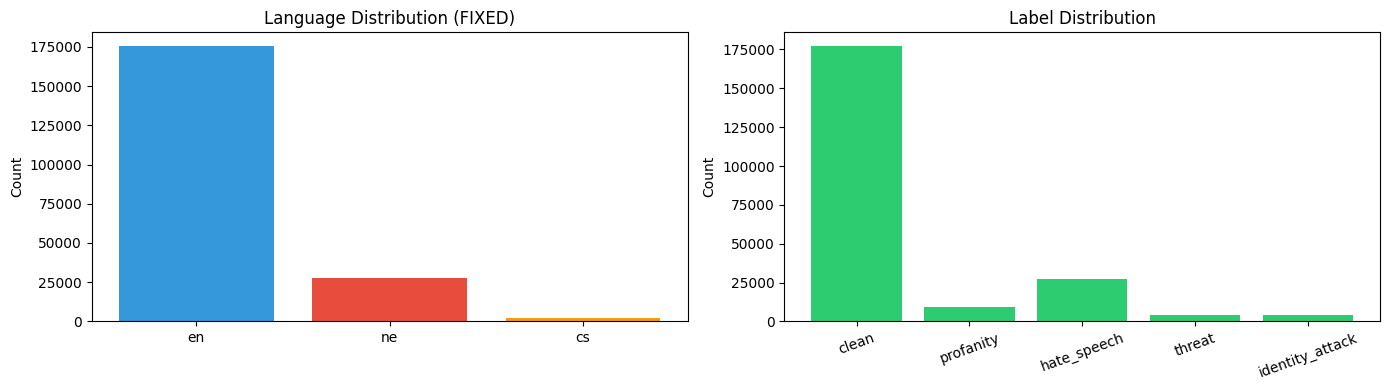


Nepali clean/hate balance check:
  clean:      23,217 (83.5%)
  hate_speech:4,585 (16.5%)


In [16]:
full_raw_df = (
    pd.concat(all_dfs, ignore_index=True)
      .drop_duplicates(subset=["text"])
      .reset_index(drop=True)
)
print(f"Combined dataset: {len(full_raw_df):,} rows")
print(f"  English:       {(full_raw_df['language']=='en').sum():,}")
print(f"  Nepali:        {(full_raw_df['language']=='ne').sum():,}")
print(f"  Code-switched: {(full_raw_df['language']=='cs').sum():,}")
print()
print("Label distribution:")
for lbl in LABELS:
    n = full_raw_df[lbl].sum()
    print(f"  {lbl:20s}: {n:6,} ({100*n/len(full_raw_df):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lang_counts = full_raw_df["language"].value_counts()
axes[0].bar(lang_counts.index, lang_counts.values, color=["#3498db","#e74c3c","#f39c12"])
axes[0].set_title("Language Distribution (FIXED)")
axes[0].set_ylabel("Count")
label_sums = full_raw_df[LABELS].sum()
axes[1].bar(LABELS, label_sums.values, color="#2ecc71")
axes[1].set_title("Label Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "dataset_distribution.png"), dpi=100, bbox_inches="tight")
plt.show()

# Verify clean Nepali class is no longer negligible
ne_df = full_raw_df[full_raw_df["language"] == "ne"]
print(f"\nNepali clean/hate balance check:")
print(f"  clean:      {ne_df['clean'].sum():,} ({100*ne_df['clean'].mean():.1f}%)")
print(f"  hate_speech:{ne_df['hate_speech'].sum():,} ({100*ne_df['hate_speech'].mean():.1f}%)")


## Synthetic Nepali via NLLB-200-distilled-600M

Using `facebook/nllb-200-distilled-600M` (fast distilled model) for Nepali translation.
With NEHATE providing 1,888 native hate tweets, we reduce `SYNTH_SAMPLE_SIZE` to 2,000.
BLEU-based back-translation QC (threshold 0.4) filters low-quality translations.
Bidirectional: EN→NE and NE→EN so the model sees the same concepts in both languages.

In [17]:
from transformers import AutoTokenizer as NLLBTokenizer, AutoModelForSeq2SeqLM
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

SYNTH_SAMPLE_SIZE    = 3000   # reduced — NEHATE fills native hate gap
BACK_TRANS_THRESHOLD = 0.4
TRANS_BATCH_SIZE     = 8
NLLB_MODEL           = "facebook/nllb-200-distilled-600M"  # fast, fits in budget

synth_ne_df  = None
synth_en_rev = None

try:
    print(f"Loading {NLLB_MODEL}...")
    nllb_tok = NLLBTokenizer.from_pretrained(NLLB_MODEL)
    nllb_mdl = AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL).to(DEVICE)
    print("NLLB model loaded.")

    def translate_batch(texts, src_lang, tgt_lang, model, tokenizer):
        tokenizer.src_lang = src_lang
        enc = tokenizer(
            texts, return_tensors="pt", padding=True,
            truncation=True, max_length=200
        ).to(DEVICE)
        with torch.no_grad():
            out = model.generate(
                **enc,
                forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_lang),
                max_length=200, num_beams=4
            )
        return tokenizer.batch_decode(out, skip_special_tokens=True)

    def bleu_score(reference, hypothesis):
        ref_tokens = reference.lower().split()
        hyp_tokens = hypothesis.lower().split()
        if not ref_tokens or not hyp_tokens:
            return 0.0
        smoother = SmoothingFunction().method1
        return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoother)

    # ── EN -> NE ────────────────────────────────────────────────────────
    en_pool    = full_raw_df[full_raw_df["language"] == "en"].copy()
    hate_pool  = en_pool[en_pool["hate_speech"] == 1].sample(
        min(SYNTH_SAMPLE_SIZE // 2, len(en_pool[en_pool["hate_speech"] == 1])), random_state=SEED)
    clean_pool = en_pool[en_pool["hate_speech"] == 0].sample(
        min(SYNTH_SAMPLE_SIZE // 2, len(en_pool[en_pool["hate_speech"] == 0])), random_state=SEED)
    sample_en  = pd.concat([hate_pool, clean_pool], ignore_index=True)
    print(f"Selected {len(sample_en):,} English samples for EN->NE translation")

    translated_rows = []
    texts = sample_en["text"].astype(str).str[:200].tolist()

    print("EN -> NE translation...")
    for i in tqdm(range(0, len(texts), TRANS_BATCH_SIZE), desc="EN->NE"):
        batch = texts[i:i + TRANS_BATCH_SIZE]
        try:
            ne_texts   = translate_batch(batch, "eng_Latn", "npi_Deva", nllb_mdl, nllb_tok)
            back_texts = translate_batch(ne_texts, "npi_Deva", "eng_Latn", nllb_mdl, nllb_tok)
            for j, (orig, ne_t, back_t) in enumerate(zip(batch, ne_texts, back_texts)):
                score = bleu_score(orig, back_t)
                if score >= BACK_TRANS_THRESHOLD:
                    row = sample_en.iloc[i + j][LABELS].to_dict()
                    row["text"] = ne_t
                    row["language"] = "ne"
                    translated_rows.append(row)
        except Exception as e:
            print(f"  Batch {i} failed: {e}")

    synth_ne_df = (
        pd.DataFrame(translated_rows)[LABELS + ["text", "language"]]
          .drop_duplicates(subset=["text"])
          .reset_index(drop=True)
    )
    print(f"Synthetic NE (EN->NE): {len(synth_ne_df):,} / {len(sample_en):,} passed QC")

    # ── NE -> EN (reverse) ───────────────────────────────────────────────
    native_ne = full_raw_df[
        (full_raw_df["language"] == "ne") & (full_raw_df["hate_speech"] == 1)
    ].sample(min(800, (full_raw_df["language"] == "ne").sum()), random_state=SEED)

    rev_rows = []
    ne_texts_rev = native_ne["text"].astype(str).str[:200].tolist()
    print(f"\nNE -> EN reverse translation ({len(ne_texts_rev)} samples)...")
    for i in tqdm(range(0, len(ne_texts_rev), TRANS_BATCH_SIZE), desc="NE->EN"):
        batch = ne_texts_rev[i:i + TRANS_BATCH_SIZE]
        try:
            en_texts = translate_batch(batch, "npi_Deva", "eng_Latn", nllb_mdl, nllb_tok)
            for j, en_t in enumerate(en_texts):
                row = native_ne.iloc[i + j][LABELS].to_dict()
                row["text"] = en_t
                row["language"] = "en"
                rev_rows.append(row)
        except Exception as e:
            print(f"  Reverse batch {i} failed: {e}")

    synth_en_rev = (
        pd.DataFrame(rev_rows)[LABELS + ["text", "language"]]
          .drop_duplicates(subset=["text"])
          .reset_index(drop=True)
    )
    print(f"Reverse-translated EN: {len(synth_en_rev):,} rows")

    # ── Merge ────────────────────────────────────────────────────────────
    extra = [synth_ne_df]
    if synth_en_rev is not None:
        extra.append(synth_en_rev)
    full_raw_df = (
        pd.concat([full_raw_df] + extra, ignore_index=True)
          .drop_duplicates(subset=["text"])
          .reset_index(drop=True)
    )
    print(f"\nFinal dataset size: {len(full_raw_df):,}")
    print(f"  English:       {(full_raw_df['language']=='en').sum():,}")
    print(f"  Nepali:        {(full_raw_df['language']=='ne').sum():,}")
    print(f"  Code-switched: {(full_raw_df['language']=='cs').sum():,}")

    del nllb_mdl
    torch.cuda.empty_cache()

except Exception as e:
    print(f"Translation pipeline failed: {e}")
    print("Proceeding without synthetic data.")


Loading facebook/nllb-200-distilled-600M...


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

NLLB model loaded.
Selected 3,000 English samples for EN->NE translation
EN -> NE translation...


EN->NE:   0%|          | 0/375 [00:00<?, ?it/s]

Synthetic NE (EN->NE): 771 / 3,000 passed QC

NE -> EN reverse translation (800 samples)...


NE->EN:   0%|          | 0/100 [00:00<?, ?it/s]

Reverse-translated EN: 800 rows

Final dataset size: 206,842
  English:       176,369
  Nepali:        28,532
  Code-switched: 1,941


## Train / Val / Test Split

**Key fix**: We oversample Nepali and code-switched rows 10x in the training set
using `WeightedRandomSampler` instead of naive concat, so the model sees them
proportionally without distorting the validation/test distributions.

Stratified 80/10/10 split on `hate_speech` label. Nepali and code-switched test
splits are tracked separately for per-language reporting.


In [18]:
train_df, temp_df = train_test_split(
    full_raw_df, test_size=0.20, random_state=SEED,
    stratify=full_raw_df["hate_speech"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED,
    stratify=temp_df["hate_speech"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Split summary:")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    en = (df["language"]=="en").sum()
    ne = (df["language"]=="ne").sum()
    cs = (df["language"]=="cs").sum()
    hs = df["hate_speech"].sum()
    print(f"  {name}: {len(df):6,} | EN={en:,} NE={ne:,} CS={cs:,} | "
          f"hate_speech={hs:,} ({100*hs/len(df):.1f}%)")

train_df.to_csv(os.path.join(WORK_DIR, "train_split.csv"), index=False)
val_df.to_csv(os.path.join(WORK_DIR,   "val_split.csv"),   index=False)
test_df.to_csv(os.path.join(WORK_DIR,  "test_split.csv"),  index=False)
print("Splits saved.")


Split summary:
  Train: 165,473 | EN=141,094 NE=22,826 CS=1,553 | hate_speech=22,735 (13.7%)
  Val: 20,684 | EN=17,587 NE=2,902 CS=195 | hate_speech=2,842 (13.7%)
  Test: 20,685 | EN=17,688 NE=2,804 CS=193 | hate_speech=2,842 (13.7%)
Splits saved.


In [19]:
# xlm-roberta-base: ~270M params, fits comfortably on T4 with batch=32.
# Faster than large (~560M) while still providing strong multilingual representations.
MODEL_NAME = "xlm-roberta-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {MODEL_NAME} | Vocab: {tokenizer.vocab_size:,}")

for lang, text in [
    ("English",       "I hate people like you, get out"),
    ("Nepali (Dev)",  "तिमि हरु यहाँ बाट जाउ"),
    ("Code-switched", "yo sala banda, I will report you"),
]:
    toks = tokenizer(text, return_tensors="pt")
    print(f"  {lang:20s}: {toks['input_ids'].shape[1]} tokens")


class HateSpeechDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts      = df["text"].tolist()
        self.labels     = df[LABELS].values.astype(np.float32)
        self.languages  = df["language"].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.float),
            "language":       self.languages[idx],
        }


BATCH_SIZE = 32   # base model fits batch=32 on T4 comfortably
GRAD_ACCUM = 1    # no accumulation needed for base model

train_dataset = HateSpeechDataset(train_df, tokenizer)
val_dataset   = HateSpeechDataset(val_df,   tokenizer)
test_dataset  = HateSpeechDataset(test_df,  tokenizer)

# WeightedRandomSampler: oversample NE + CS rows
lang_series  = train_df["language"]
lang_weights = {"en": 1.0, "ne": 10.0, "cs": 8.0}
sample_wts   = lang_series.map(lang_weights).fillna(1.0).values
sampler      = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_wts),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"Effective batch size: {BATCH_SIZE}")


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: xlm-roberta-base | Vocab: 250,002
  English             : 10 tokens
  Nepali (Dev)        : 10 tokens
  Code-switched       : 10 tokens
Train batches: 5172 | Val: 647 | Test: 647
Effective batch size: 32


In [20]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=5, problem_type="multi_label_classification"
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ── Language-aware BCE loss ──────────────────────────────────────────────
# Nepali and code-switched batches get 3x loss weight so the model
# can't ignore them despite being a small fraction of data.
label_counts = train_df[LABELS].sum().values.astype(float)
N            = len(train_df)
pos_weights  = torch.tensor(
    [(N - c) / max(c, 1) for c in label_counts], dtype=torch.float
).to(DEVICE)

class LanguageAwareBCELoss(nn.Module):
    """
    BCEWithLogitsLoss with per-sample language weight:
      English:       1.0x
      Code-switched: 2.5x
      Nepali:        3.0x
    """
    LANG_WEIGHT = {"en": 1.0, "ne": 3.0, "cs": 2.5}

    def __init__(self, pos_weight):
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, logits, targets, languages):
        # element-wise loss: (batch, num_labels)
        loss = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=self.pos_weight,
            reduction="none"
        )
        # per-sample weight: (batch,)
        w = torch.tensor(
            [self.LANG_WEIGHT.get(l, 1.0) for l in languages],
            dtype=torch.float, device=logits.device
        )
        return (loss * w.unsqueeze(1)).mean()


criterion = LanguageAwareBCELoss(pos_weights)
print("\nClass pos_weights:")
for lbl, w in zip(LABELS, pos_weights.cpu()):
    print(f"  {lbl:20s}: {w:.2f}")


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: xlm-roberta-base
Total parameters:     278,047,493
Trainable parameters: 278,047,493

Class pos_weights:
  clean               : 0.16
  profanity           : 20.88
  hate_speech         : 6.28
  threat              : 47.30
  identity_attack     : 47.27


In [21]:
EPOCHS       = 5
LR           = 2e-5
WEIGHT_DECAY = 0.01
PATIENCE     = 2   # stop if no improvement for 2 consecutive epochs

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps  = len(train_loader) * EPOCHS   # GRAD_ACCUM=1, so no division needed
warmup_steps = int(0.10 * total_steps)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

SAVE_DIR = os.path.join(WORK_DIR, "hatespeech-best")
os.makedirs(SAVE_DIR, exist_ok=True)

best_val_f1      = 0.0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_per_class_f1": []}

print(f"{'='*70}")
print(f"  TRAINING — up to {EPOCHS} epochs | early stopping patience={PATIENCE}")
print(f"  Model: {MODEL_NAME} | LR={LR} | Batch={BATCH_SIZE}")
print(f"{'='*70}\n")


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            lbls  = batch["labels"].to(device)
            langs = batch["language"]
            out   = model(input_ids=ids, attention_mask=mask)
            loss  = criterion(out.logits, lbls, langs)
            total_loss += loss.item()
            all_logits.append(out.logits.cpu().numpy())
            all_labels.append(lbls.cpu().numpy())
    return (total_loss / len(loader),
            np.concatenate(all_logits), np.concatenate(all_labels))


for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=True)

    for step, batch in pbar:
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        lbls  = batch["labels"].to(DEVICE)
        langs = batch["language"]

        out  = model(input_ids=ids, attention_mask=mask)
        loss = criterion(out.logits, lbls, langs)
        loss.backward()
        epoch_loss += loss.item()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        if (step + 1) % 200 == 0:
            pbar.set_postfix({"loss": f"{epoch_loss/(step+1):.4f}"})

    avg_train_loss = epoch_loss / len(train_loader)
    val_loss, val_logits, val_labels = evaluate(model, val_loader, criterion, DEVICE)
    val_preds    = (torch.sigmoid(torch.tensor(val_logits)) >= 0.5).numpy().astype(int)
    val_macro_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)
    val_per_cls  = f1_score(val_labels, val_preds, average=None,    zero_division=0)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_per_class_f1"].append(val_per_cls.tolist())

    print(f"\nEpoch {epoch} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Macro F1: {val_macro_f1:.4f}")
    for lbl, f1v in zip(LABELS, val_per_cls):
        print(f"  {lbl:20s}: F1={f1v:.4f}")

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        patience_counter = 0
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"  ✓ Best checkpoint saved (val macro F1={best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  Early stopping triggered at epoch {epoch}.")
            break

print(f"\nTraining complete. Best val macro F1: {best_val_f1:.4f}")


  TRAINING — up to 5 epochs | early stopping patience=2
  Model: xlm-roberta-base | LR=2e-05 | Batch=32



Epoch 1/5 [Train]:   0%|          | 0/5172 [00:00<?, ?it/s]


Epoch 1 | Train Loss: 0.8344 | Val Loss: 0.4794 | Val Macro F1: 0.6518
  clean               : F1=0.9515
  profanity           : F1=0.6919
  hate_speech         : F1=0.7424
  threat              : F1=0.4430
  identity_attack     : F1=0.4303


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best checkpoint saved (val macro F1=0.6518)


...


Epoch 4 | Train Loss: 0.1949 | Val Loss: 0.7933 | Val Macro F1: 0.7522
  clean               : F1=0.9646
  profanity           : F1=0.7692
  hate_speech         : F1=0.7880
  threat              : F1=0.5994
  identity_attack     : F1=0.6400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best checkpoint saved (val macro F1=0.7522)


Epoch 5/5 [Train]:   0%|          | 0/5172 [00:00<?, ?it/s]


Epoch 5 | Train Loss: 0.1574 | Val Loss: 0.7061 | Val Macro F1: 0.7506
  clean               : F1=0.9619
  profanity           : F1=0.7730
  hate_speech         : F1=0.7826
  threat              : F1=0.5971
  identity_attack     : F1=0.6386
  No improvement (1/2)

Training complete. Best val macro F1: 0.7522


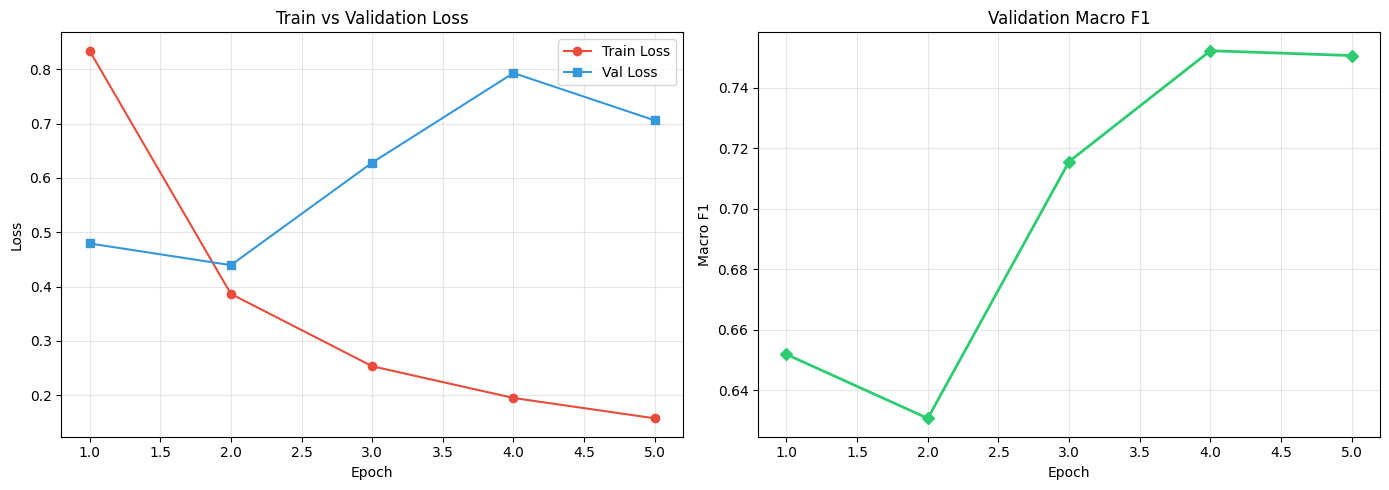

In [22]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history["train_loss"], "o-", label="Train Loss", color="#e74c3c")
ax1.plot(epochs_ran, history["val_loss"],   "s-", label="Val Loss",   color="#3498db")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Train vs Validation Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history["val_macro_f1"], "D-", color="#2ecc71", linewidth=2)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Macro F1"); ax2.set_title("Validation Macro F1")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "training_curves.png"), dpi=100, bbox_inches="tight")
plt.show()


## Per-Language Threshold Tuning

A single 0.5 threshold does not work equally well across all languages.
The Nepali model over-triggers on clean Nepali (false positives).
We calibrate per-language thresholds on the validation set to maximize
per-language macro F1, then apply them at test time.


In [23]:
best_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(DEVICE)
print(f"Best model loaded from {SAVE_DIR}")

# collect val set predictions with language info
best_model.eval()
val_logits_all, val_labels_all, val_langs_all = [], [], []
with torch.no_grad():
    for batch in val_loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        out  = best_model(input_ids=ids, attention_mask=mask)
        val_logits_all.append(out.logits.cpu().numpy())
        val_labels_all.append(batch["labels"].numpy())
        val_langs_all.extend(batch["language"])

val_logits_all = np.concatenate(val_logits_all)
val_labels_all = np.concatenate(val_labels_all)
val_probs_all  = torch.sigmoid(torch.tensor(val_logits_all)).numpy()
val_langs_all  = np.array(val_langs_all)

THRESHOLDS = {}
THRESHOLD_GRID = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

print("\nPer-language threshold tuning on validation set:")
for lang in ["en", "ne", "cs"]:
    mask = val_langs_all == lang
    if mask.sum() < 10:
        THRESHOLDS[lang] = 0.5
        print(f"  {lang}: too few samples, using default 0.5")
        continue
    best_f1, best_t = 0.0, 0.5
    for t in THRESHOLD_GRID:
        preds  = (val_probs_all[mask] >= t).astype(int)
        macro  = f1_score(val_labels_all[mask], preds, average="macro", zero_division=0)
        if macro > best_f1:
            best_f1, best_t = macro, t
    THRESHOLDS[lang] = best_t
    print(f"  {lang}: best threshold={best_t:.2f}  (val macro F1={best_f1:.4f})")

print(f"\nFinal thresholds: {THRESHOLDS}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Best model loaded from /kaggle/working/hatespeech-best

Per-language threshold tuning on validation set:
  en: best threshold=0.65  (val macro F1=0.7573)
  ne: best threshold=0.35  (val macro F1=0.7528)
  cs: best threshold=0.30  (val macro F1=0.5728)

Final thresholds: {'en': 0.65, 'ne': 0.35, 'cs': 0.3}


In [24]:
# Full evaluation using per-language thresholds
best_model.eval()
test_logits_all, test_labels_all, test_langs_all = [], [], []
with torch.no_grad():
    for batch in test_loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        out  = best_model(input_ids=ids, attention_mask=mask)
        test_logits_all.append(out.logits.cpu().numpy())
        test_labels_all.append(batch["labels"].numpy())
        test_langs_all.extend(batch["language"])

test_logits_all = np.concatenate(test_logits_all)
test_labels_arr = np.concatenate(test_labels_all)
test_probs_all  = torch.sigmoid(torch.tensor(test_logits_all)).numpy()
test_langs_all  = np.array(test_langs_all)

# Apply per-language thresholds
test_preds = np.zeros_like(test_probs_all, dtype=int)
for lang, thresh in THRESHOLDS.items():
    mask = test_langs_all == lang
    if mask.sum() > 0:
        test_preds[mask] = (test_probs_all[mask] >= thresh).astype(int)
# fallback for any unlabeled language
unlabeled = ~np.isin(test_langs_all, list(THRESHOLDS.keys()))
test_preds[unlabeled] = (test_probs_all[unlabeled] >= 0.5).astype(int)

print("=" * 70)
print("  TEST SET — OVERALL RESULTS (per-language thresholds)")
print("=" * 70)
print(classification_report(test_labels_arr, test_preds, target_names=LABELS, zero_division=0))

overall_macro_f1    = f1_score(test_labels_arr, test_preds, average="macro",    zero_division=0)
overall_weighted_f1 = f1_score(test_labels_arr, test_preds, average="weighted", zero_division=0)
overall_accuracy    = accuracy_score(test_labels_arr.flatten(), test_preds.flatten())
print(f"Overall Accuracy:    {overall_accuracy:.4f}")
print(f"Overall Macro F1:    {overall_macro_f1:.4f}")
print(f"Overall Weighted F1: {overall_weighted_f1:.4f}")


  TEST SET — OVERALL RESULTS (per-language thresholds)
                 precision    recall  f1-score   support

          clean       0.97      0.95      0.96     17751
      profanity       0.68      0.90      0.78       952
    hate_speech       0.78      0.81      0.80      2842
         threat       0.59      0.65      0.62       444
identity_attack       0.60      0.74      0.66       444

      micro avg       0.92      0.92      0.92     22433
      macro avg       0.73      0.81      0.76     22433
   weighted avg       0.92      0.92      0.92     22433
    samples avg       0.92      0.93      0.92     22433

Overall Accuracy:    0.9649
Overall Macro F1:    0.7632
Overall Weighted F1: 0.9219


In [25]:
print("=" * 70)
print("  TEST SET — BY LANGUAGE (with tuned thresholds)")
print("=" * 70)

lang_results = {}
for lang, lang_name in [("en", "English"), ("ne", "Nepali"), ("cs", "Code-switched")]:
    mask = test_langs_all == lang
    if mask.sum() == 0:
        print(f"  {lang_name}: No samples in test set.")
        continue
    l_true  = test_labels_arr[mask]
    l_pred  = test_preds[mask]
    l_macro = f1_score(l_true, l_pred, average="macro", zero_division=0)
    l_per   = f1_score(l_true, l_pred, average=None,    zero_division=0)
    l_acc   = accuracy_score(l_true.flatten(), l_pred.flatten())
    lang_results[lang_name] = {
        "macro_f1": l_macro, "accuracy": l_acc,
        "threshold": THRESHOLDS.get(lang, 0.5),
        "per_class": dict(zip(LABELS, l_per.tolist()))
    }
    print(f"\n  {lang_name} ({mask.sum()} samples | threshold={THRESHOLDS.get(lang,0.5):.2f}):")
    print(f"    Accuracy:  {l_acc:.4f}")
    print(f"    Macro F1:  {l_macro:.4f}")
    for lbl, f1 in zip(LABELS, l_per):
        print(f"      {lbl:20s}: F1={f1:.4f}")

print("\n" + "=" * 50)
print(f"{'Language':<15} {'Accuracy':<12} {'Macro F1':<12} {'Threshold'}")
print("-" * 50)
for ln, res in lang_results.items():
    print(f"{ln:<15} {res['accuracy']:.4f}       {res['macro_f1']:.4f}       {res['threshold']:.2f}")


  TEST SET — BY LANGUAGE (with tuned thresholds)

  English (17688 samples | threshold=0.65):
    Accuracy:  0.9652
    Macro F1:  0.7639
      clean               : F1=0.9663
      profanity           : F1=0.7749
      hate_speech         : F1=0.8016
      threat              : F1=0.6140
      identity_attack     : F1=0.6626

  Nepali (2804 samples | threshold=0.35):
    Accuracy:  0.9609
    Macro F1:  0.7361
      clean               : F1=0.9474
      profanity           : F1=0.6733
      hate_speech         : F1=0.7569
      threat              : F1=0.6875
      identity_attack     : F1=0.6154

  Code-switched (193 samples | threshold=0.30):
    Accuracy:  0.9917
    Macro F1:  0.5820
      clean               : F1=0.9908
      profanity           : F1=0.9667
      hate_speech         : F1=0.9524
      threat              : F1=0.0000
      identity_attack     : F1=0.0000

Language        Accuracy     Macro F1     Threshold
--------------------------------------------------
English 

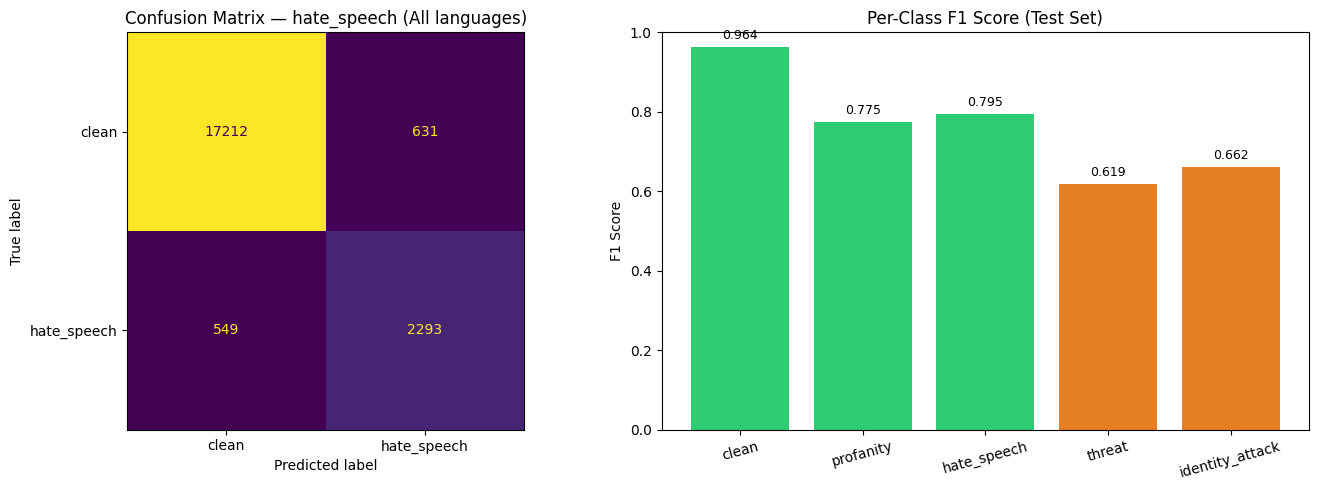

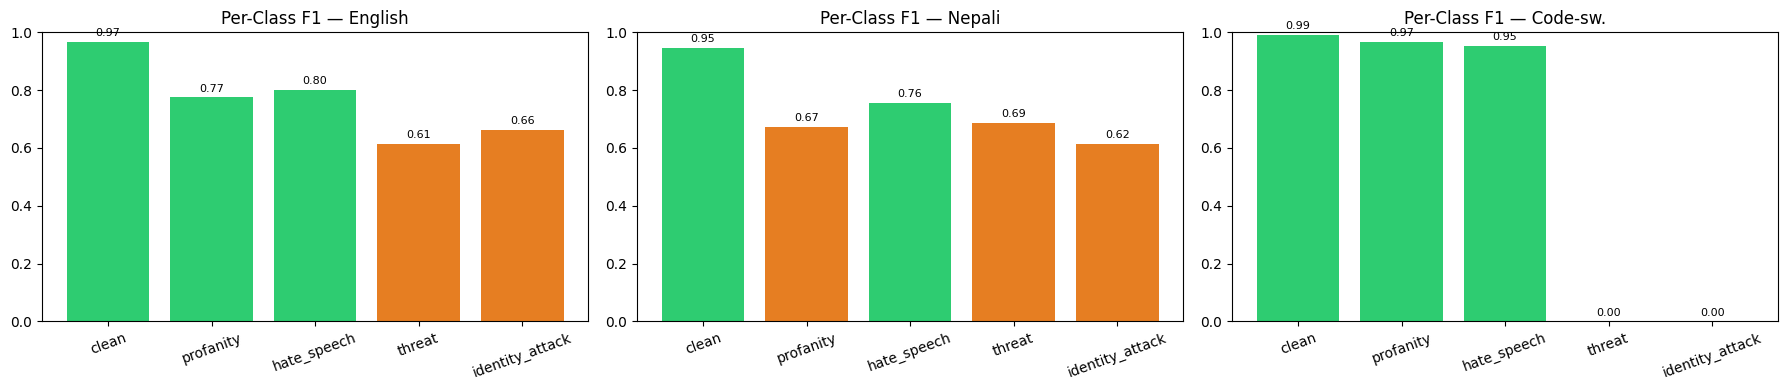

In [26]:
hs_idx  = LABELS.index("hate_speech")
hs_true = test_labels_arr[:, hs_idx].astype(int)
hs_pred = test_preds[:, hs_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(hs_true, hs_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["clean", "hate_speech"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — hate_speech (All languages)")

final_per_cls = f1_score(test_labels_arr, test_preds, average=None, zero_division=0)
colors = ["#2ecc71" if f > 0.7 else "#e67e22" if f > 0.4 else "#e74c3c" for f in final_per_cls]
axes[1].bar(LABELS, final_per_cls, color=colors)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Class F1 Score (Test Set)")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(final_per_cls):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "test_evaluation.png"), dpi=100, bbox_inches="tight")
plt.show()

# Per-language per-class F1 heatmap
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
for ax, (lang, lang_name) in zip(axes2, [("en","English"),("ne","Nepali"),("cs","Code-sw.")]):
    mask = test_langs_all == lang
    if mask.sum() == 0:
        ax.set_visible(False); continue
    per_cls = f1_score(test_labels_arr[mask], test_preds[mask], average=None, zero_division=0)
    colors2 = ["#2ecc71" if f > 0.7 else "#e67e22" if f > 0.4 else "#e74c3c" for f in per_cls]
    ax.bar(LABELS, per_cls, color=colors2)
    ax.set_ylim(0, 1); ax.set_title(f"Per-Class F1 — {lang_name}")
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(per_cls):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "per_language_f1.png"), dpi=100, bbox_inches="tight")
plt.show()


In [28]:
FINAL_DIR = os.path.join(WORK_DIR, "guardmeet-xlmr-final")
os.makedirs(FINAL_DIR, exist_ok=True)
best_model.save_pretrained(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)

with open(os.path.join(FINAL_DIR, "label_map.json"), "w") as f:
    json.dump({i: lbl for i, lbl in enumerate(LABELS)}, f, indent=2)

with open(os.path.join(FINAL_DIR, "thresholds.json"), "w") as f:
    json.dump(THRESHOLDS, f, indent=2)

metrics_out = {
    "model": MODEL_NAME,
    "epochs_trained": len(history["train_loss"]),
    "best_val_macro_f1": best_val_f1,
    "test_macro_f1_overall": overall_macro_f1,
    "test_weighted_f1": overall_weighted_f1,
    "language_results": lang_results,
    "thresholds": THRESHOLDS,
    "baseline_tfidf_macro_f1": baseline_f1,
    "history": history
}
with open(os.path.join(WORK_DIR, "training_metrics.json"), "w") as f:
    json.dump(metrics_out, f, indent=2)

print(f"Model + thresholds saved to {FINAL_DIR}")
print(f"Metrics saved to training_metrics.json")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model + thresholds saved to /kaggle/working/guardmeet-xlmr-final
Metrics saved to training_metrics.json


In [29]:
def detect_script(text):
    """Fast character-level language/script detection."""
    dev = sum(1 for c in text if '\u0900' <= c <= '\u097F')
    lat = sum(1 for c in text if c.isascii() and c.isalpha())
    if dev > 0 and lat > 0:
        return "cs"
    elif dev > lat:
        return "ne"
    else:
        # check for Romanized Nepali markers
        t = text.lower()
        ne_markers = ["bro","yaar","ni","ta","ko","ma","le","lai",
                      "cha","chha","ho","gara","garnu","kasto","aaja"]
        ne_hits = sum(1 for w in ne_markers if f" {w} " in f" {t} ")
        return "cs" if ne_hits >= 2 else "en"


def predict(text, model, tokenizer, thresholds=THRESHOLDS):
    model.eval()
    lang = detect_script(text)
    thresh = thresholds.get(lang, 0.5)
    enc = tokenizer(
        text, max_length=128, padding="max_length",
        truncation=True, return_tensors="pt"
    )
    with torch.no_grad():
        logits = model(
            input_ids=enc["input_ids"].to(DEVICE),
            attention_mask=enc["attention_mask"].to(DEVICE)
        ).logits
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    return {
        "language": lang,
        "threshold_used": thresh,
        "labels": {
            lbl: {"prob": float(f"{p:.4f}"), "flagged": bool(p >= thresh)}
            for lbl, p in zip(LABELS, probs)
        }
    }


demo_sentences = [
    ("English — hate",          "I hate people like you, get out of here"),
    ("English — threat",        "I will hurt you if you say that again"),
    ("English — identity",      "People from that community are all criminals"),
    ("English — clean",         "Great meeting everyone, see you next week!"),
    ("Nepali — hate (Devanag)", "तिमि हरु यहाँ बाट जाउ, मलाई घृणा लाग्छ"),
    ("Nepali — threat",         "म हान्छु गोली अब आयेर सबै चोरहरुलाई"),
    ("Nepali — CLEAN (was broken)", "यस्ता नेता भय पो हून्छ देस मा बिकास।"),
    ("Code-switch — hate",      "yo sala banda, get out of this meeting"),
    ("Code-switch — threat",    "band gar yo bakwas natra ma report garchu admin lai"),
    ("Code-switch — clean",     "bro can you share screen, mero side ma dekhena"),
    ("Code-switch — profanity", "kasto bakwas presentation ho yaar, total faltoo"),
    ("Romanized NE — clean",    "aaja meeting kati bajey start hunchha bro?"),
]

print("=" * 75)
print("  SAMPLE INFERENCE (per-language thresholds applied)")
print("=" * 75)

for label, text in demo_sentences:
    result  = predict(text, best_model, tokenizer)
    lbls    = result["labels"]
    flagged = [k for k, v in lbls.items() if v["flagged"] and k != "clean"]
    top     = max(lbls.items(), key=lambda x: x[1]["prob"])
    print(f"\n[{label}]")
    print(f"  Text      : {text[:65]}")
    print(f"  Detected  : {result['language']} | Threshold: {result['threshold_used']:.2f}")
    print(f"  Flagged   : {flagged if flagged else 'none (clean)'}")
    print(f"  Top class : {top[0]} ({top[1]['prob']:.4f})")
    for lbl, v in lbls.items():
        bar  = "|" * int(v["prob"] * 20)
        flag = " <- FLAGGED" if v["flagged"] and lbl != "clean" else ""
        print(f"    {lbl:20s} {v['prob']:.4f} {bar}{flag}")


  SAMPLE INFERENCE (per-language thresholds applied)

[English — hate]
  Text      : I hate people like you, get out of here
  Detected  : en | Threshold: 0.65
  Flagged   : ['hate_speech']
  Top class : hate_speech (0.9115)
    clean                0.0673 |
    profanity            0.0197 
    hate_speech          0.9115 |||||||||||||||||| <- FLAGGED
    threat               0.0227 
    identity_attack      0.0157 

[English — threat]
  Text      : I will hurt you if you say that again
  Detected  : en | Threshold: 0.65
  Flagged   : none (clean)
  Top class : hate_speech (0.6497)
    clean                0.2669 |||||
    profanity            0.0632 |
    hate_speech          0.6497 ||||||||||||
    threat               0.3999 |||||||
    identity_attack      0.1007 ||

[English — identity]
  Text      : People from that community are all criminals
  Detected  : en | Threshold: 0.65
  Flagged   : ['hate_speech']
  Top class : hate_speech (0.6964)
    clean                0.2402 ||||
 